## Imports and paths


In [19]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from windrose import WindroseAxes
import seaborn as sns


# ── Paths ──────────────────────────────────────────────────────
MERGED_DIR  = Path("../data/merged")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WAVE_FILE = MERGED_DIR / "era5_waves_2014_2024.nc"

# ── Load wave data ─────────────────────────────────────────────
ds_wave = xr.open_dataset(WAVE_FILE)

## Calm Weather Statistics by Season


In [20]:
# 1. Compute Calm Weather Statistics by Season
# Extract significant wave height (swh) and group by season
# 'DJF' = Winter, 'MAM' = Spring, 'JJA' = Summer, 'SON' = Autumn

# Grouping the xarray data by season
seasonal_hs = ds_wave["swh"].mean(dim=["latitude", "longitude"], skipna=True).groupby("time.season")

# Mapping dictionary for full names
season_map = {
    "DJF": "Winter (Dec-Feb)",
    "MAM": "Spring (Mar-May)",
    "JJA": "Summer (Jun-Aug)",
    "SON": "Autumn (Sep-Nov)"
}

thresholds = [0.5, 1.0, 1.5]
stats_list = []

for season_code, group in seasonal_hs:
    season_total = group.count().values
    # Use the map to get the full name
    row = {"Season": season_map.get(season_code, season_code)}
    
    for t in thresholds:
        calm_count = (group < t).sum().values
        percentage = (calm_count / season_total) * 100
        row[f"Hs < {t}m (%)"] = round(percentage, 2)
    
    stats_list.append(row)

# Create DataFrame
df_calm = pd.DataFrame(stats_list).set_index("Season")

# Reorder logically (Spring -> Summer -> Autumn -> Winter)
logical_order = ["Spring (Mar-May)", "Summer (Jun-Aug)", "Autumn (Sep-Nov)", "Winter (Dec-Feb)"]
df_calm = df_calm.reindex(logical_order)

print("--- Calm Weather Statistics (Operational Windows) ---")
print("Note: These statistics are critical for determining marine construction")
print("downtime and port accessibility limits.")
display(df_calm)

# Save to CSV
csv_path = FIGURES_DIR / "calm_weather_stats.csv"
df_calm.to_csv(csv_path)
print(f"\nSaved → {csv_path}")

--- Calm Weather Statistics (Operational Windows) ---
Note: These statistics are critical for determining marine construction
downtime and port accessibility limits.


,Hs < 0.5m (%),Hs < 1.0m (%),Hs < 1.5m (%)
Season,,,
Spring (Mar-May),8.15,76.45,95.51
Summer (Jun-Aug),47.85,95.79,99.76
Autumn (Sep-Nov),16.59,49.93,71.64
Winter (Dec-Feb),0.00,23.64,53.16



Saved → ../outputs/figures/calm_weather_stats.csv


## Joint Probability Table ($H_s \times T_p$)


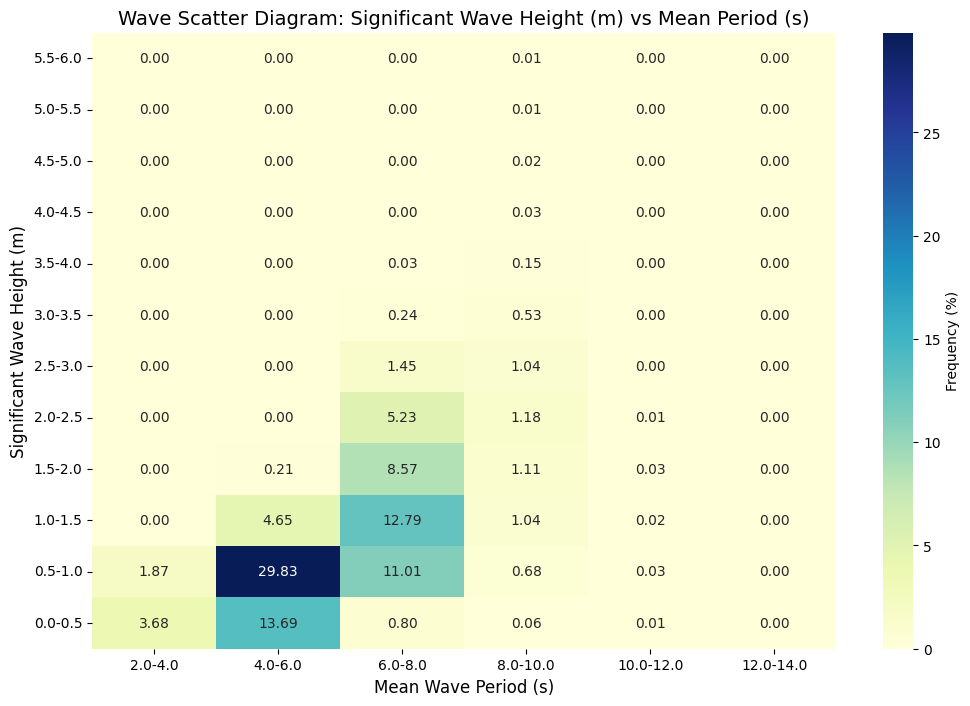

Scatter diagram successfully saved to ../outputs/figures


In [21]:
# Using 'mwp' (Mean Wave Period) as indicated by your dataset variables
tp = ds_wave["mwp"].mean(dim=["latitude", "longitude"], skipna=True).to_series()
hs = ds_wave["swh"].mean(dim=["latitude", "longitude"], skipna=True).to_series()

# Define logical bins for Hs (0.5m steps) and Tp (2s steps)
hs_bins = np.arange(0, hs.max() + 0.5, 0.5)
tp_bins = np.arange(0, tp.max() + 2, 2)

# Create binned categories
hs_cut = pd.cut(hs, bins=hs_bins)
tp_cut = pd.cut(tp, bins=tp_bins)

# Generate Cross-tabulation (Frequency Table)
# normalize=True gives us the proportion; multiplying by 100 gives percentage
jp_table = pd.crosstab(hs_cut, tp_cut, normalize=True) * 100

# Format the index/columns for cleaner display (optional but recommended)
jp_table.index = [f"{idx.left}-{idx.right}" for idx in jp_table.index]
jp_table.columns = [f"{col.left}-{col.right}" for col in jp_table.columns]

# Plotting the Scatter Diagram
plt.figure(figsize=(12, 8))
sns.heatmap(jp_table, annot=True, fmt=".2f", cmap="YlGnBu", 
            cbar_kws={'label': 'Frequency (%)'})

plt.title("Wave Scatter Diagram: Significant Wave Height (m) vs Mean Period (s)", fontsize=14)
plt.xlabel("Mean Wave Period (s)", fontsize=12)
plt.ylabel("Significant Wave Height (m)", fontsize=12)
plt.gca().invert_yaxis()  # Standard convention: height increases upwards

# Save the figure
plt.savefig(FIGURES_DIR / "wave_scatter_diagram.png", dpi=300, bbox_inches='tight')
plt.yticks(rotation=0) # Keeps the wave height labels horizontal
plt.show()

print(f"Scatter diagram successfully saved to {FIGURES_DIR}")